In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlopen
from io import BytesIO
from zipfile import ZipFile

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Dataset: Read, EDA & Preprocessing
Dataset Source: [Click Here](https://archive.ics.uci.edu/dataset/236/seed)

The seven features are:

1. Area
2. Perimeter
3. Compactness
4. Kernel Length
5. Kernel Width
6. Asymmetry Coefficient
7. Kernel Groove Length

The column "Wheat Class" will be excluded during implementation because PCA operates only on the input features. The class label is **not used when calculating PCA** as it is an unsupervised linear dimensionality reduction technique. This column will be used later for visualization only.

In [ ]:
# Load the Seeds Dataset directly from UC Irvine Machine Learning Repository

dataset_url = "https://archive.ics.uci.edu/static/public/236/seeds.zip"

feature_names = ["Area", "Perimeter", "Compactness", "Kernel Length",
                "Kernel Width", "Asymmetry Coefficient", "Kernel Groove Length"]

column_names = feature_names + ["Wheat Class"]

with urlopen(dataset_url) as response:
    zip_data = BytesIO(response.read())

with ZipFile(zip_data) as zip_file:
    # print("Files inside ZIP:", zip_file.namelist())
    with zip_file.open("seeds_dataset.txt") as data_file:
        dataset_df = pd.read_csv(data_file, sep = r"\s+", header = None, names = column_names)

dataset_df

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length,Wheat Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [ ]:
# Making sure all columns are numeric
dataset_df = dataset_df.apply(pd.to_numeric, errors="coerce")

# Remove incomplete rows, if any
dataset_df = dataset_df.dropna().reset_index(drop=True);

# Convert class labels to integers
dataset_df["Wheat Class"] = dataset_df["Wheat Class"].astype(int)

# Add readable wheat variety names
class_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
dataset_df["Wheat Variety"] = dataset_df["Wheat Class"].map(class_names)

dataset_df

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length,Wheat Class,Wheat Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama
...,...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3,Canadian
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3,Canadian
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3,Canadian
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3,Canadian


In [ ]:
# Separate features and target

X_df = dataset_df[feature_names].copy()
X = X_df.to_numpy(dtype=float)

y = dataset_df["Wheat Class"].to_numpy()
wheat_varieties = dataset_df["Wheat Variety"].to_numpy()

print("Dataset shape:", dataset_df.shape)
print("Number of observations:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset shape: (210, 9)
Number of observations: 210
Number of features: 7


In [ ]:
print("Class distribution:")
dataset_df["Wheat Variety"].value_counts()

Class distribution:


,count
Wheat Variety,
Kama,70
Rosa,70
Canadian,70


In [ ]:
print("Missing values:")
dataset_df.isnull().sum()

Missing values:


,0
Area,0
Perimeter,0
Compactness,0
Kernel Length,0
Kernel Width,0
Asymmetry Coefficient,0
Kernel Groove Length,0
Wheat Class,0
Wheat Variety,0


In [ ]:
# Descriptive Statistics
X_df.describe().round(4)

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length
count,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000
mean,14.8475,14.5593,0.8710,5.6285,3.2586,3.7002,5.4081
std,2.9097,1.3060,0.0236,0.4431,0.3777,1.5036,0.4915
min,10.5900,12.4100,0.8081,4.8990,2.6300,0.7651,4.5190
25%,12.2700,13.4500,0.8569,5.2622,2.9440,2.5615,5.0450
50%,14.3550,14.3200,0.8734,5.5235,3.2370,3.5990,5.2230
75%,17.3050,15.7150,0.8878,5.9798,3.5618,4.7688,5.8770
max,21.1800,17.2500,0.9183,6.6750,4.0330,8.4560,6.5500


# Principal Component Analysis (PCA): Library Implementation
Documentation Link: [Click Here](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [ ]:
# Standardize the Features

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

standardized_df = pd.DataFrame(X_standardized, columns=feature_names)
standardized_df.head()

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356


In [ ]:
print("Means after standardization:")
print(standardized_df.mean().round(1))

print()

print("Standard deviations after standardization:")
print(standardized_df.std().round(1))

Means after standardization:
Area                    -0.0
Perimeter                0.0
Compactness              0.0
Kernel Length           -0.0
Kernel Width            -0.0
Asymmetry Coefficient   -0.0
Kernel Groove Length    -0.0
dtype: float64

Standard deviations after standardization:
Area                     1.0
Perimeter                1.0
Compactness              1.0
Kernel Length            1.0
Kernel Width             1.0
Asymmetry Coefficient    1.0
Kernel Groove Length     1.0
dtype: float64


In [ ]:
# Scikit-Learn Implementation

pca = PCA() # Keep all components initially

X_pca_all = pca.fit_transform(X_standardized)

principal_component_names = [f"PC{i}" for i in range(1, X_pca_all.shape[1] + 1)]

all_components_df = pd.DataFrame(X_pca_all, columns=principal_component_names)
all_components_df.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0.317047,-0.783669,-0.631010,-0.416846,0.107496,0.022570,-0.014697
1,-0.003386,-1.913214,-0.669754,-0.433071,-0.044406,0.018921,-0.005479
2,-0.459443,-1.907225,0.932489,-0.111292,0.008222,-0.051313,-0.004177
3,-0.591936,-1.931069,0.499311,-0.228977,-0.074853,0.229500,-0.010051
4,1.102910,-2.068090,0.056705,-0.142421,-0.018775,0.052639,-0.000622
5,-0.336815,-1.636916,0.438913,-0.098189,0.006180,-0.022215,-0.008781
6,-0.145602,-0.436415,0.301945,-0.112315,0.072079,-0.059857,-0.024917
7,-0.425440,-1.390153,0.401288,-0.069178,0.050502,0.084806,-0.007270
8,1.767184,-0.307529,-0.968166,0.238217,0.140403,0.097146,-0.029849
9,1.441194,-1.011068,-0.383042,0.005999,0.103647,0.062820,-0.008249


In [ ]:
print("Number of Components:", pca.n_components_)
print("Number of Samples:", pca.n_samples_)

Number of Components: 7
Number of Samples: 210


In [ ]:
print("Sorted Eigenvalues:", pca.explained_variance_)
print()
print("Corresponding Sorted Eigenvectors:", pca.components_)

Sorted Eigenvalues: [5.05527392e+00 1.20330286e+00 6.81247474e-01 6.86915798e-02
 1.88031478e-02 5.35755786e-03 8.16283866e-04]

Corresponding Sorted Eigenvectors: [[ 0.44447352  0.44157147  0.27701737  0.42356333  0.43281866 -0.11869248
   0.38716084]
 [ 0.02656355  0.08400282 -0.52915125  0.20597518 -0.11668963  0.71688203
   0.37719327]
 [ 0.02587094 -0.05983912  0.62969178 -0.21187966  0.21648338  0.67950584
  -0.2138972 ]
 [-0.19363997 -0.29545659  0.3328164  -0.26340659 -0.19963039 -0.09246481
   0.80414995]
 [-0.20441167 -0.17427591  0.33265481  0.76609839 -0.46536555  0.03625822
  -0.11134657]
 [-0.42643686 -0.47623853 -0.14162884  0.27357647  0.70301171 -0.01964186
   0.04282974]
 [ 0.73480569 -0.67075153 -0.0725527   0.04627605 -0.03928908 -0.00372346
  -0.0344981 ]]


In [ ]:
print(pca.explained_variance_ratio_)

[7.18743027e-01 1.71081835e-01 9.68576341e-02 9.76635386e-03
 2.67337271e-03 7.61720812e-04 1.16056686e-04]


In [ ]:
# Explained Variance

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

variance_df = pd.DataFrame({
    "Principal Component": principal_component_names,
    "Eigenvalue": pca.explained_variance_,
    "Explained Variance (%)": explained_variance_ratio * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})


variance_df.round(4)

,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,5.0553,71.8743,71.8743
1,PC2,1.2033,17.1082,88.9825
2,PC3,0.6812,9.6858,98.6682
3,PC4,0.0687,0.9766,99.6449
4,PC5,0.0188,0.2673,99.9122
5,PC6,0.0054,0.0762,99.9884
6,PC7,0.0008,0.0116,100.0000


In [ ]:
# Principal Component Coefficients
component_df = pd.DataFrame(pca.components_.T, index=feature_names, columns=principal_component_names)
component_df.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Area,0.4445,0.0266,0.0259,-0.1936,-0.2044,-0.4264,0.7348
Perimeter,0.4416,0.0840,-0.0598,-0.2955,-0.1743,-0.4762,-0.6708
Compactness,0.2770,-0.5292,0.6297,0.3328,0.3327,-0.1416,-0.0726
Kernel Length,0.4236,0.2060,-0.2119,-0.2634,0.7661,0.2736,0.0463
Kernel Width,0.4328,-0.1167,0.2165,-0.1996,-0.4654,0.7030,-0.0393
Asymmetry Coefficient,-0.1187,0.7169,0.6795,-0.0925,0.0363,-0.0196,-0.0037
Kernel Groove Length,0.3872,0.3772,-0.2139,0.8041,-0.1113,0.0428,-0.0345


In [ ]:
# Creating a Two-Component PCA Dataframe
# [you can also create by using: pca = PCA(n_components = 2)]

pca_df = pd.DataFrame({"PC1": X_pca_all[:, 0], "PC2": X_pca_all[:, 1],
            "Wheat Class": y, "Wheat Variety": wheat_varieties})

variance_retained = explained_variance_ratio[:2].sum() * 100
print(f"Variance retained by PC1 and PC2: {variance_retained:.2f}%")

pca_df.head(10)

Variance retained by PC1 and PC2: 88.98%


,PC1,PC2,Wheat Class,Wheat Variety
0,0.317047,-0.783669,1,Kama
1,-0.003386,-1.913214,1,Kama
2,-0.459443,-1.907225,1,Kama
3,-0.591936,-1.931069,1,Kama
4,1.102910,-2.068090,1,Kama
5,-0.336815,-1.636916,1,Kama
6,-0.145602,-0.436415,1,Kama
7,-0.425440,-1.390153,1,Kama
8,1.767184,-0.307529,1,Kama
9,1.441194,-1.011068,1,Kama


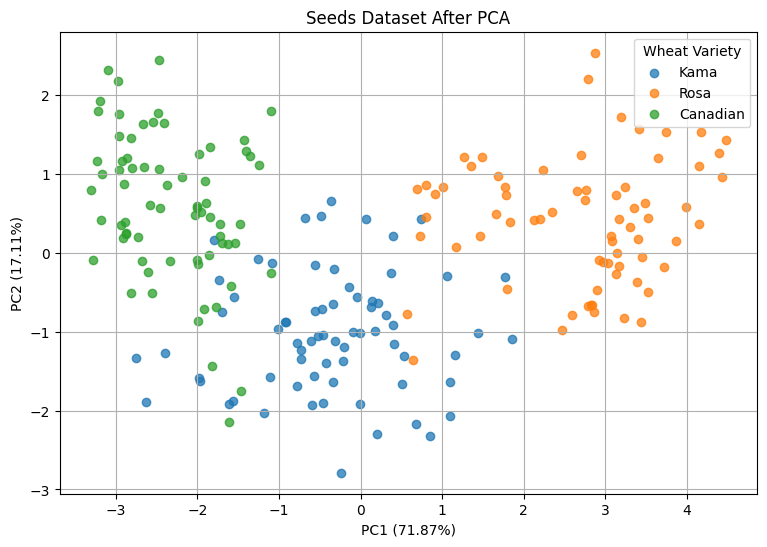

In [ ]:
# Visualize PC1 and PC2

plt.figure(figsize=(9, 6))

for variety in pca_df["Wheat Variety"].unique():
    class_data = pca_df[pca_df["Wheat Variety"] == variety]

    plt.scatter(class_data["PC1"], class_data["PC2"],
        label=variety, alpha=0.75)

plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.2f}%)")
plt.title("Seeds Dataset After PCA")

plt.grid()
plt.legend(title="Wheat Variety")

plt.show()

PCA Analysis from the [Introductory Paper](https://www.semanticscholar.org/paper/24a9453d3cab64995e32506f884c2a1792a6d4ca) of the Dataset:
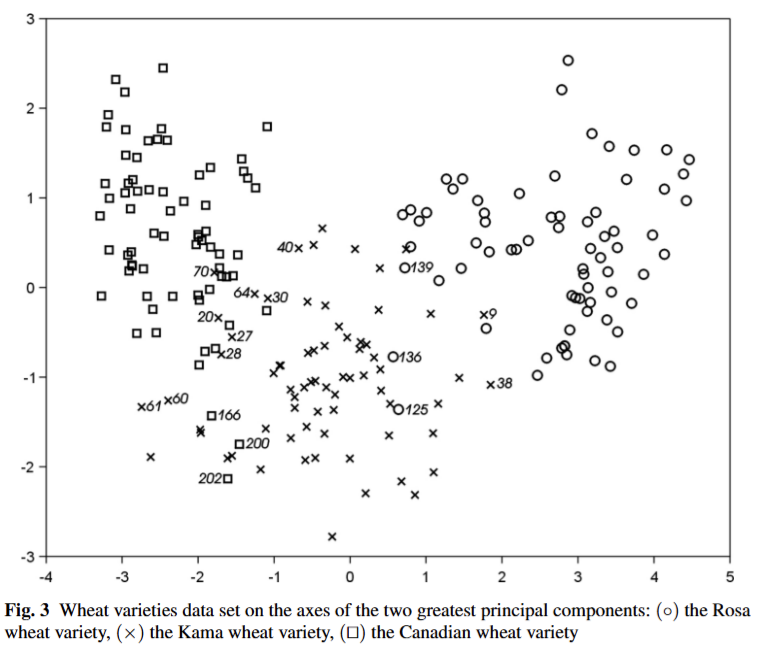

In [ ]:
# Data Reconstruction
original_df = pd.DataFrame(X, columns=feature_names)

# Data Reconstruction using all the components
X_reconstructed_scaled_all = pca.inverse_transform(X_pca_all)
X_reconstructed_original_all = scaler.inverse_transform(X_reconstructed_scaled_all)

# comparison
reconstructed_df_all = pd.DataFrame(X_reconstructed_original_all, columns=feature_names)
comparison_df_all = pd.DataFrame()

for feature in feature_names:
    comparison_df_all[f"Original {feature}"] = original_df[feature]
    comparison_df_all[f"Reconstructed {feature}"] = reconstructed_df_all[feature]

print("Original vs Reconstructed:")
comparison_df_all.head(10).round(4)

Original vs Reconstructed:


,Original Area,Reconstructed Area,Original Perimeter,Reconstructed Perimeter,Original Compactness,Reconstructed Compactness,Original Kernel Length,Reconstructed Kernel Length,Original Kernel Width,Reconstructed Kernel Width,Original Asymmetry Coefficient,Reconstructed Asymmetry Coefficient,Original Kernel Groove Length,Reconstructed Kernel Groove Length
0,15.26,15.26,14.84,14.84,0.8710,0.8710,5.763,5.763,3.312,3.312,2.221,2.221,5.220,5.220
1,14.88,14.88,14.57,14.57,0.8811,0.8811,5.554,5.554,3.333,3.333,1.018,1.018,4.956,4.956
2,14.29,14.29,14.09,14.09,0.9050,0.9050,5.291,5.291,3.337,3.337,2.699,2.699,4.825,4.825
3,13.84,13.84,13.94,13.94,0.8955,0.8955,5.324,5.324,3.379,3.379,2.259,2.259,4.805,4.805
4,16.14,16.14,14.99,14.99,0.9034,0.9034,5.658,5.658,3.562,3.562,1.355,1.355,5.175,5.175
5,14.38,14.38,14.21,14.21,0.8951,0.8951,5.386,5.386,3.312,3.312,2.462,2.462,4.956,4.956
6,14.69,14.69,14.49,14.49,0.8799,0.8799,5.563,5.563,3.259,3.259,3.586,3.586,5.219,5.219
7,14.11,14.11,14.10,14.10,0.8911,0.8911,5.420,5.420,3.302,3.302,2.700,2.700,5.000,5.000
8,16.63,16.63,15.46,15.46,0.8747,0.8747,6.053,6.053,3.465,3.465,2.040,2.040,5.877,5.877
9,16.44,16.44,15.25,15.25,0.8880,0.8880,5.884,5.884,3.505,3.505,1.969,1.969,5.533,5.533


In [ ]:
# Data Reconstruction using the first two components

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_standardized)

X_reconstructed_scaled_2 = pca_2.inverse_transform(X_pca_2)
X_reconstructed_original_2 = scaler.inverse_transform(X_reconstructed_scaled_2)

# comparison
reconstructed_df_2 = pd.DataFrame(X_reconstructed_original_2, columns=feature_names)
comparison_df_2 = pd.DataFrame()

for feature in feature_names:
    comparison_df_2[f"Original {feature}"] = original_df[feature]
    comparison_df_2[f"Reconstructed {feature}"] = reconstructed_df_2[feature]

print("Original vs Reconstructed:")
comparison_df_2.head(10).round(4)

Original vs Reconstructed:


,Original Area,Reconstructed Area,Original Perimeter,Reconstructed Perimeter,Original Compactness,Reconstructed Compactness,Original Kernel Length,Reconstructed Kernel Length,Original Kernel Width,Reconstructed Kernel Width,Original Asymmetry Coefficient,Reconstructed Asymmetry Coefficient,Original Kernel Groove Length,Reconstructed Kernel Groove Length
0,15.26,15.1962,14.84,14.6559,0.8710,0.8828,5.763,5.6165,3.312,3.3448,2.221,2.8011,5.220,5.3233
1,14.88,14.6956,14.57,14.3480,0.8811,0.8948,5.554,5.4537,3.333,3.3422,1.018,1.6435,4.956,5.0536
2,14.29,14.1077,14.09,14.0862,0.9050,0.8918,5.291,5.3689,3.337,3.2675,2.699,1.7312,4.825,4.9681
3,13.84,13.9349,13.94,14.0074,0.8955,0.8912,5.324,5.3419,3.379,3.2470,2.259,1.7291,4.805,4.9386
4,16.14,16.1110,14.99,14.9675,0.9034,0.9040,5.658,5.6467,3.562,3.5294,1.355,1.2800,5.175,5.2350
5,14.38,14.2867,14.21,14.1864,0.8951,0.8892,5.386,5.4164,3.312,3.2756,2.462,2.0000,4.956,5.0414
6,14.69,14.6260,14.49,14.4278,0.8799,0.8755,5.563,5.5615,3.259,3.2540,3.586,3.2568,5.219,5.2997
7,14.11,14.1914,14.10,14.1624,0.8911,0.8856,5.420,5.4223,3.302,3.2503,2.700,2.2811,5.000,5.0702
8,16.63,17.1038,15.46,15.5423,0.8747,0.8864,6.053,5.9314,3.465,3.5603,2.040,3.0549,5.877,5.6867
9,16.44,16.6290,15.25,15.2777,0.8880,0.8930,5.884,5.8063,3.505,3.5381,1.969,2.3564,5.533,5.4947


# Principal Component Analysis (PCA) from Scratch

For the Seeds dataset, we have:

* Number of observations, $n$ = 210
* Number of input features, $d$ = 7
* Number of wheat classes = 3


---

## Step 1: Prepare the Feature Matrix

Suppose the dataset contains $n$ observations and $d$ numerical features.

The feature matrix can be represented as:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1d} \\
x_{21} & x_{22} & \cdots & x_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{nd}
\end{bmatrix}
$$

For the Seeds dataset:

$$
X \in \mathbb{R}^{210 \times 7}
$$

---

## Step 2: Standardize the Dataset
Since the Seeds dataset features have different measurement scales, the features should be standardized (or at least mean-centered) before applying PCA.

For each feature $j$, calculate its mean:

$$
\mu_j =
\frac{1}{n}
\sum_{i=1}^{n} x_{ij}
$$


The mean vector is:
$$
\mu = [\mu_1, \mu_2, \ldots, \mu_d]
$$

For the Seeds dataset:
$$
\mu = [\mu_1, \mu_2, \mu_3, \mu_4, \mu_5, \mu_6, \mu_7]
$$

These mean values represent the center of each feature.

---

For each feature $j$, calculate its standard deviation:

$$
\sigma_j =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(x_{ij}-\mu_j)^2
}
$$

The standard deviation measures how much the values of a feature vary around its mean.

---
Each value is standardized using:

$$
 z_{ij} = \frac{x_{ij}-\mu_j}{\sigma_j}
$$

Therefore, the standardized feature matrix becomes:

$$
X_{Standardized} =
\begin{bmatrix}
z_{11} & z_{12} & \cdots & z_{1d} \\
z_{21} & z_{22} & \cdots & z_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
z_{n1} & z_{n2} & \cdots & z_{nd}
\end{bmatrix}
$$

After standardization, each feature has approximately: $
\text{Mean = 0 }
\&
\text{ Standard Deviation = 1}
$

This prevents features with larger numerical values from dominating the PCA calculation.

---

## Step 3: Calculate the Covariance Matrix

The next step is to determine how the standardized features vary together.

The covariance matrix is calculated as:

$$
C =
\frac{1}{n-1} X_{Standardized}^T X_{Standardized}
$$

where $n$ is the number of observations.

For the Seeds dataset:

$$
X_{Standardized} \in \mathbb{R}^{210 \times 7}
$$


and the covariance matrix has dimensions:

$$
C \in \mathbb{R}^{7 \times 7}
$$

The covariance matrix has the general form:

$$
C =
\begin{bmatrix}
\operatorname{Cov}(x_1,x_1) & \operatorname{Cov}(x_1,x_2) & \cdots & \operatorname{Cov}(x_1,x_7) \\
\operatorname{Cov}(x_2,x_1) & \operatorname{Cov}(x_2,x_2) & \cdots & \operatorname{Cov}(x_2,x_7) \\
\vdots & \vdots & \ddots & \vdots \\
\operatorname{Cov}(x_7,x_1) & \operatorname{Cov}(x_7,x_2) & \cdots & \operatorname{Cov}(x_7,x_7)
\end{bmatrix}
$$

A positive covariance means two features tend to increase together, while a negative covariance means one tends to decrease when the other increases.

---

## Step 4: Calculate Eigenvalues and Eigenvectors

The principal directions are obtained from the covariance matrix by solving:

$$
Cv = \lambda v
$$

where:

* $C$ = covariance matrix
* $\lambda$ = eigenvalue
* $v$ = eigenvector

Equivalently:

$$
(C-\lambda I)v=0
$$

To obtain the eigenvalues, solve:

$$
\det(C-\lambda I)=0
$$

Since the Seeds dataset contains seven features, the covariance matrix produces:

$$
\lambda_1,\lambda_2,\lambda_3,\ldots,\lambda_7
$$

and seven corresponding eigenvectors:

$$
v_1,v_2,v_3,\ldots,v_7
$$

Each eigenvector represents a possible principal-component direction.

Each eigenvalue represents the amount of variance captured along that direction.

---

## Step 5: Sort the Eigenvalues

The eigenvalues are arranged from largest to smallest:

$$
\lambda_1 \geq
\lambda_2 \geq
\lambda_3 \geq
\cdots \geq
\lambda_7
$$

The corresponding eigenvectors must also be rearranged in the same order.

Therefore:

$$
PC_1 \rightarrow v_1
$$

$$
PC_2 \rightarrow v_2
$$

$$
PC_3 \rightarrow v_3
$$

and so on.

The eigenvector corresponding to the largest eigenvalue becomes the **first principal component**.

---

## Step 6: Calculate the Explained Variance Ratio

The total variance in the dataset is:

$$
\text{Total Variance} = \sum_{j=1}^{d}\lambda_j
$$

For the Seeds dataset:

$$
\text{Total Variance} = \lambda_1+\lambda_2+\cdots+\lambda_7
$$

The explained variance ratio of principal component $i$ is:

$$
EVR_i = \frac{\lambda_i} {\sum_{j=1}^{d}\lambda_j}
$$

To express it as a percentage:

$$
\text{$EV_i$(%)} =
\frac{\lambda_i} {\sum_{j=1}^{d}\lambda_j} \times 100
$$

For example:

$$
\text{$EV_1$(%)} =
\frac{\lambda_1} {\lambda_1+\lambda_2+\cdots+\lambda_7} \times 100
$$

This tells us how much information is represented by PC1.

---

## Step 7: Calculate Cumulative Explained Variance

Sometimes one principal component is not sufficient. The cumulative explained variance for the first $k$ components is:

$$
CEV_k = \sum_{i=1}^{k}EVR_i
$$

For example, the variance retained using PC1 and PC2 is:

$$
CEV_2 = EVR_1+EVR_2
$$

or in percentage form:

$$
\text{$CEV_2$(%)} = \text{$EV_1$(%)} + \text{$EV_2$(%)}
$$

This value tells us how much information is retained when the original seven-dimensional dataset is reduced to two dimensions.

---

## Step 8: Select the Principal Components

Suppose we want to reduce the Seeds dataset from:

$$
7D \rightarrow 2D
$$

We select the eigenvectors corresponding to the two largest eigenvalues:

$$
W =
\begin{bmatrix}
| & | \\
v_1 & v_2 \\
| & |
\end{bmatrix}
$$

Since every eigenvector has seven elements:

$$
W \in \mathbb{R}^{7 \times 2}
$$

This matrix is called the **projection matrix**.

---

## Step 9: Project the Original Data

The standardized data is projected onto the selected principal-component directions:

$$
X_{PCA}=X_{Standardized}W
$$

For the Seeds dataset:

$$
(210\times7)(7\times2) = 210\times2
$$

Therefore:

$$
X_{PCA}
\in
\mathbb{R}^{210\times2}
$$

The resulting matrix contains:

$$
X_{PCA} =
\begin{bmatrix}
PC1_1 & PC2_1 \\
PC1_2 & PC2_2 \\
\vdots & \vdots \\
PC1_{210} & PC2_{210}
\end{bmatrix}
$$

Thus, each wheat sample is now represented by only two values instead of seven.

---

## Step 10: Interpret the Principal Components

Each principal component is a linear combination of the original standardized features.

For example:

$$
PC_1 = w_{11}z_1 + w_{21}z_2 + w_{31}z_3 + \cdots+ w_{71}z_7
$$

Similarly:

$$
PC_2 = w_{12}z_1 + w_{22}z_2 + w_{32}z_3 + \cdots + w_{72}z_7
$$

The coefficients $w$ come from the eigenvectors.

Large positive or negative coefficients indicate that a feature has a strong influence on that principal component.

---

## Step 11: Reconstruct the Original Data

### Reconstruct the Standardized Data:

To transform the PCA data back toward the original feature space, multiply by the transpose of the projection matrix:

$$
\hat{X}_{Standardized} = X_{PCA}W^T
$$

We get:

$$
(210 \times 2)(2 \times 7) = 210 \times 7
$$

Therefore:

$$
\hat{X}_{Standardized} \in \mathbb{R}^{210 \times 7}
$$

Here, $\hat{X}_{Standardized}$ represents the reconstructed standardized dataset.

---

### Reverse the Standardization:

During preprocessing, each original feature was standardized using:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

To return to the original measurement scale, rearrange the equation:

$$
\hat{x}_{ij} = \hat{z}_{ij}\sigma_j + \mu_j
$$

Therefore, the reconstructed dataset is:

$$
\hat{X} = \hat{X}_{Standardized}\sigma + \mu
$$

where:

- $\hat{X}$ = reconstructed data in the original feature scale
- $\hat{X}_{Standardized}$ = reconstructed standardized data
- $\sigma$ = original feature standard deviations
- $\mu$ = original feature means

---

If only 2 out of the 7 principal components are retained:

$$
7D \rightarrow 2D \rightarrow 7D
$$

the reconstructed data will only be an **approximation** of the original data.

This happens because PC3, PC4, ..., PC7 were discarded during dimensionality reduction.

Therefore:

$$
\hat{X} \approx X
$$

not necessarily:

$$
\hat{X} = X
$$

If all 7 principal components are retained, then almost all information is preserved and:

$$
\hat{X} \approx X
$$

with only very small numerical differences caused by floating-point calculations.

---

In [ ]:
# Standardize the Features

feature_means = np.mean(X, axis= 0)
feature_standard_deviations = np.std(X, axis= 0)

X_standardized = (X - feature_means) / feature_standard_deviations

# sanity check
print("Means after standardization:")
print(np.mean(X_standardized, axis=0).round(1))

print("\nStandard deviations after standardization:")
print(np.std(X_standardized, axis=0).round(1))

Means after standardization:
[-0.  0.  0. -0. -0. -0. -0.]

Standard deviations after standardization:
[1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Calculate the Covariance Matrix
number_of_samples = X_standardized.shape[0]
covariance_matrix = np.matmul(X_standardized.T, X_standardized) /(number_of_samples -1)

covariance_df = pd.DataFrame(covariance_matrix, index=feature_names, columns=feature_names)
covariance_df.round(4)

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length
Area,1.0048,0.9991,0.6112,0.9545,0.9754,-0.2307,0.8678
Perimeter,0.9991,1.0048,0.5318,0.9771,0.9494,-0.2184,0.8950
Compactness,0.6112,0.5318,1.0048,0.3697,0.7653,-0.3331,0.2279
Kernel Length,0.9545,0.9771,0.3697,1.0048,0.8645,-0.1724,0.9373
Kernel Width,0.9754,0.9494,0.7653,0.8645,1.0048,-0.2593,0.7527
Asymmetry Coefficient,-0.2307,-0.2184,-0.3331,-0.1724,-0.2593,1.0048,-0.0111
Kernel Groove Length,0.8678,0.8950,0.2279,0.9373,0.7527,-0.0111,1.0048


In [ ]:
# Calculate eigenvalues and eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix )

print(eigenvalues) # unsorted

# sort eigenvalues and eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

principal_component_names = [f"PC{i}" for i in range(1, len(eigenvalues) + 1)]
for component, eigenvalue in zip(principal_component_names, eigenvalues):
    print(f"{component}: {eigenvalue:.4f}")

[8.16283866e-04 5.35755786e-03 1.88031478e-02 6.86915798e-02
 6.81247474e-01 1.20330286e+00 5.05527392e+00]
PC1: 5.0553
PC2: 1.2033
PC3: 0.6812
PC4: 0.0687
PC5: 0.0188
PC6: 0.0054
PC7: 0.0008


In [ ]:
# explained variance

explained_variance_ratio = eigenvalues /np.sum(eigenvalues)

cumulative_explained_variance = np.cumsum(explained_variance_ratio)

variance_df = pd.DataFrame({
    "Principal Component": principal_component_names, "Eigenvalue": eigenvalues,
    "Explained Variance": explained_variance_ratio, "Explained Variance (%)": explained_variance_ratio * 100,
    "Cumulative Variance (%)": cumulative_explained_variance * 100
})

variance_df.round(4)

,Principal Component,Eigenvalue,Explained Variance,Explained Variance (%),Cumulative Variance (%)
0,PC1,5.0553,0.7187,71.8743,71.8743
1,PC2,1.2033,0.1711,17.1082,88.9825
2,PC3,0.6812,0.0969,9.6858,98.6682
3,PC4,0.0687,0.0098,0.9766,99.6449
4,PC5,0.0188,0.0027,0.2673,99.9122
5,PC6,0.0054,0.0008,0.0762,99.9884
6,PC7,0.0008,0.0001,0.0116,100.0000


In [ ]:
# select the first two principal components

number_of_components = 2
selected_eigenvectors = eigenvectors[:, :number_of_components ] # projection matrix (W)

selected_eigenvectors_df = pd.DataFrame(selected_eigenvectors, index=feature_names, columns=["PC1", "PC2"])
selected_eigenvectors_df.round(4)

,PC1,PC2
Area,-0.4445,-0.0266
Perimeter,-0.4416,-0.0840
Compactness,-0.2770,0.5292
Kernel Length,-0.4236,-0.2060
Kernel Width,-0.4328,0.1167
Asymmetry Coefficient,0.1187,-0.7169
Kernel Groove Length,-0.3872,-0.3772


In [ ]:
retained_variance = explained_variance_ratio[:number_of_components].sum()* 100
print(f"Variance retained by PC1 and PC2: {retained_variance:.2f}%")

Variance retained by PC1 and PC2: 88.98%


In [ ]:
# data projection onto principal components

X_pca = np.matmul(X_standardized,selected_eigenvectors)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Wheat Class"] = y

pca_df.head(10)

,PC1,PC2,Wheat Class
0,-0.317047,0.783669,1
1,0.003386,1.913214,1
2,0.459443,1.907225,1
3,0.591936,1.931069,1
4,-1.102910,2.068090,1
5,0.336815,1.636916,1
6,0.145602,0.436415,1
7,0.425440,1.390153,1
8,-1.767184,0.307529,1
9,-1.441194,1.011068,1


In [ ]:
# equations for PC1 and PC2

for pc_index in range(2):
    pc_name = f"PC{pc_index + 1}"
    terms = []

    for feature_index, feature in enumerate(feature_names):
        coefficient = selected_eigenvectors[feature_index, pc_index]
        terms.append(f"({coefficient:.4f} × {feature})")
    equation = " + ".join(terms)
    print(f"{pc_name} = {equation}")

PC1 = (-0.4445 × Area) + (-0.4416 × Perimeter) + (-0.2770 × Compactness) + (-0.4236 × Kernel Length) + (-0.4328 × Kernel Width) + (0.1187 × Asymmetry Coefficient) + (-0.3872 × Kernel Groove Length)
PC2 = (-0.0266 × Area) + (-0.0840 × Perimeter) + (0.5292 × Compactness) + (-0.2060 × Kernel Length) + (0.1167 × Kernel Width) + (-0.7169 × Asymmetry Coefficient) + (-0.3772 × Kernel Groove Length)


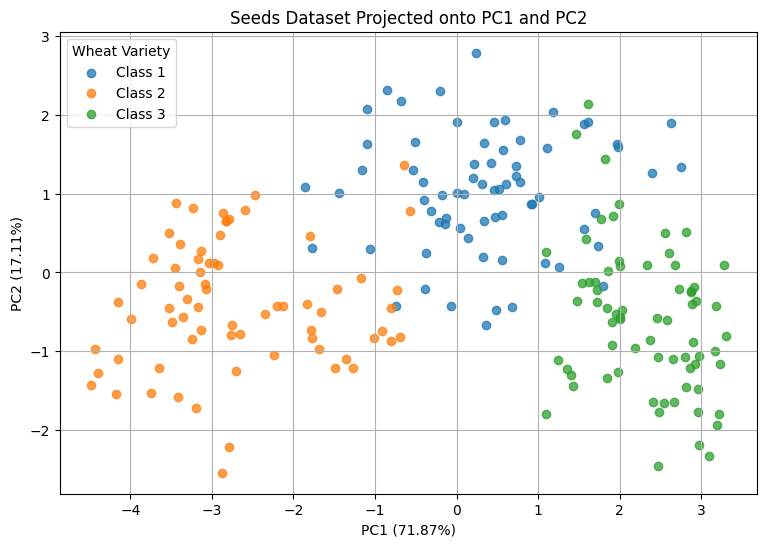

In [ ]:
# Two Dimensional PCA Visualization

plt.figure(figsize=(9, 6))

unique_classes = np.unique(y)

for wheat_class in unique_classes:
    class_rows = pca_df["Wheat Class"] == wheat_class

    plt.scatter(pca_df.loc[class_rows, "PC1"], pca_df.loc[class_rows, "PC2"],
        label=f"Class {wheat_class}", alpha=0.75)

plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.2f}%)")

plt.title("Seeds Dataset Projected onto PC1 and PC2")
plt.grid()
plt.legend(title = "Wheat Variety")
plt.show()

In [ ]:
# Data Reconstruction (using 2 components)

# Convert PCA data back to standardized feature space
X_standardized_reconstructed = np.matmul (X_pca, selected_eigenvectors.T )

# Reverse the standardization
X_reconstructed = (X_standardized_reconstructed *feature_standard_deviations) +feature_means

# Convert reconstructed data to DataFrame
reconstructed_df = pd.DataFrame(X_reconstructed, columns=feature_names)
reconstructed_df.head(10)

,Area,Perimeter,Compactness,Kernel Length,Kernel Width,Asymmetry Coefficient,Kernel Groove Length
0,15.196151,14.655916,0.882844,5.616543,3.344771,2.801073,5.323323
1,14.695631,14.347950,0.894841,5.453716,3.342177,1.643518,5.053597
2,14.107688,14.086236,0.891789,5.368879,3.267534,1.731152,4.968131
3,13.934907,14.007404,0.891221,5.341903,3.246974,1.729101,4.938571
4,16.111034,14.967452,0.903998,5.646734,3.529415,1.280019,5.234960
5,14.286746,14.186368,0.889218,5.416446,3.275649,1.999984,5.041401
6,14.626016,14.427758,0.875491,5.561542,3.254047,3.256845,5.299721
7,14.191429,14.162388,0.885561,5.422320,3.250344,2.281107,5.070214
8,17.103835,15.542289,0.886375,5.931384,3.560341,3.054893,5.686658
9,16.628993,15.277750,0.893022,5.806301,3.538109,2.356412,5.494663


In [ ]:
# Compare original and reconstructed values (using 2 components) for all features

original_df = pd.DataFrame(X, columns=feature_names)
reconstructed_df = pd.DataFrame(X_reconstructed, columns=feature_names)

comparison_df = pd.DataFrame()

for feature in feature_names:
    comparison_df[f"Original {feature}"] = original_df[feature]
    comparison_df[f"Reconstructed {feature}"] = reconstructed_df[feature]

comparison_df.head(10).round(4)

,Original Area,Reconstructed Area,Original Perimeter,Reconstructed Perimeter,Original Compactness,Reconstructed Compactness,Original Kernel Length,Reconstructed Kernel Length,Original Kernel Width,Reconstructed Kernel Width,Original Asymmetry Coefficient,Reconstructed Asymmetry Coefficient,Original Kernel Groove Length,Reconstructed Kernel Groove Length
0,15.26,15.1962,14.84,14.6559,0.8710,0.8828,5.763,5.6165,3.312,3.3448,2.221,2.8011,5.220,5.3233
1,14.88,14.6956,14.57,14.3480,0.8811,0.8948,5.554,5.4537,3.333,3.3422,1.018,1.6435,4.956,5.0536
2,14.29,14.1077,14.09,14.0862,0.9050,0.8918,5.291,5.3689,3.337,3.2675,2.699,1.7312,4.825,4.9681
3,13.84,13.9349,13.94,14.0074,0.8955,0.8912,5.324,5.3419,3.379,3.2470,2.259,1.7291,4.805,4.9386
4,16.14,16.1110,14.99,14.9675,0.9034,0.9040,5.658,5.6467,3.562,3.5294,1.355,1.2800,5.175,5.2350
5,14.38,14.2867,14.21,14.1864,0.8951,0.8892,5.386,5.4164,3.312,3.2756,2.462,2.0000,4.956,5.0414
6,14.69,14.6260,14.49,14.4278,0.8799,0.8755,5.563,5.5615,3.259,3.2540,3.586,3.2568,5.219,5.2997
7,14.11,14.1914,14.10,14.1624,0.8911,0.8856,5.420,5.4223,3.302,3.2503,2.700,2.2811,5.000,5.0702
8,16.63,17.1038,15.46,15.5423,0.8747,0.8864,6.053,5.9314,3.465,3.5603,2.040,3.0549,5.877,5.6867
9,16.44,16.6290,15.25,15.2777,0.8880,0.8930,5.884,5.8063,3.505,3.5381,1.969,2.3564,5.533,5.4947


In [ ]:
# Data Reconstruction (using all components)

number_of_components = 7

# Select all 7 eigenvectors
selected_eigenvectors = eigenvectors[ :, :number_of_components ] # replace None with your code

# Project standardized data onto all 7 PCs
X_pca = np.matmul(X_standardized, selected_eigenvectors) # replace None with your code
print("Shape after PCA:", X_pca.shape) # (210, 7)


# Convert PCA data back to standardized feature space
X_standardized_reconstructed = np.matmul(X_pca, selected_eigenvectors.T)

# Reverse standardization
X_reconstructed = (X_standardized_reconstructed *feature_standard_deviations) +feature_means # replace None with your code
reconstructed_df = pd.DataFrame(X_reconstructed, columns=feature_names)

# comparison

original_df = pd.DataFrame(X, columns=feature_names)
comparison_df = pd.DataFrame()

for feature in feature_names:
    comparison_df[f"Original {feature}"] = original_df[feature]
    comparison_df[f"Reconstructed {feature}"] = reconstructed_df[feature]

print("\nOriginal vs Reconstructed:")
comparison_df.head(10).round(4)

Shape after PCA: (210, 7)

Original vs Reconstructed:


,Original Area,Reconstructed Area,Original Perimeter,Reconstructed Perimeter,Original Compactness,Reconstructed Compactness,Original Kernel Length,Reconstructed Kernel Length,Original Kernel Width,Reconstructed Kernel Width,Original Asymmetry Coefficient,Reconstructed Asymmetry Coefficient,Original Kernel Groove Length,Reconstructed Kernel Groove Length
0,15.26,15.26,14.84,14.84,0.8710,0.8710,5.763,5.763,3.312,3.312,2.221,2.221,5.220,5.220
1,14.88,14.88,14.57,14.57,0.8811,0.8811,5.554,5.554,3.333,3.333,1.018,1.018,4.956,4.956
2,14.29,14.29,14.09,14.09,0.9050,0.9050,5.291,5.291,3.337,3.337,2.699,2.699,4.825,4.825
3,13.84,13.84,13.94,13.94,0.8955,0.8955,5.324,5.324,3.379,3.379,2.259,2.259,4.805,4.805
4,16.14,16.14,14.99,14.99,0.9034,0.9034,5.658,5.658,3.562,3.562,1.355,1.355,5.175,5.175
5,14.38,14.38,14.21,14.21,0.8951,0.8951,5.386,5.386,3.312,3.312,2.462,2.462,4.956,4.956
6,14.69,14.69,14.49,14.49,0.8799,0.8799,5.563,5.563,3.259,3.259,3.586,3.586,5.219,5.219
7,14.11,14.11,14.10,14.10,0.8911,0.8911,5.420,5.420,3.302,3.302,2.700,2.700,5.000,5.000
8,16.63,16.63,15.46,15.46,0.8747,0.8747,6.053,6.053,3.465,3.465,2.040,2.040,5.877,5.877
9,16.44,16.44,15.25,15.25,0.8880,0.8880,5.884,5.884,3.505,3.505,1.969,1.969,5.533,5.533
